In [40]:
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import timedelta
import openpyxl

EUR/USD	    Euro verso USD	EURUSD=X
USD/JPY	    USD verso Yen giapponese	JPY=X
GBP/USD	    Sterlina verso USD	GBPUSD=X
USD/CNY	    USD verso Yuan cinese	CNY=X

fed funds rate

S&P

USDCNY=X USDJPY=X

In [41]:
fed_funds = pd.read_csv(" C:\\Users\\miche\\OneDrive\\Desktop\\PROJECTS\\crude oil forecasting\\macro factors\\DFF.xlsx", sheet_name="DATA 1", engine = "openpyxl")


TypeError: read_csv() got an unexpected keyword argument 'sheet_name'

In [27]:
tickers_exchange_rates = ["EURUSD=X","GBPUSD=X","USDJPY=X","USDCNY=X", "^GSPC"]

end = dt.datetime.now()
start = end - dt.timedelta(days=365*30)

data_daily = yf.download(tickers_exchange_rates, start, end)

C:\Users\miche\AppData\Local\Temp\ipykernel_43196\787555946.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_daily = yf.download(tickers_exchange_rates, start, end)
[*********************100%***********************]  5 of 5 completed


In [28]:
data_daily = data_daily['Close'].pct_change().dropna()

C:\Users\miche\AppData\Local\Temp\ipykernel_43196\1914118299.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data_daily = data_daily['Close'].pct_change().dropna()


In [29]:
data_daily

Ticker,EURUSD=X,GBPUSD=X,USDCNY=X,USDJPY=X,^GSPC
Date,,,,,
2003-12-02,0.010360,0.006817,0.000000,-0.004030,-0.003271
2003-12-03,0.002813,-0.001279,-0.000012,-0.003955,-0.001772
2003-12-04,-0.003467,-0.004284,-0.000012,-0.000277,0.004687
2003-12-05,0.008775,0.007210,-0.000012,-0.006003,-0.007684
2003-12-08,0.002713,0.000642,0.000024,-0.001951,0.007348
...,...,...,...,...,...
2025-11-04,-0.000772,0.000039,0.007714,0.000058,-0.011737
2025-11-05,-0.002917,-0.008645,-0.005898,-0.004196,0.003654
2025-11-06,0.000977,0.002373,-0.000491,0.003360,-0.011178


In [30]:
metrics = []

for tick in tickers_exchange_rates:
    data = data_daily[tick]
    mean = data.mean()
    vol = data.std()
    kurt = data.kurtosis()
    skew = data.skew()
    metrics.append({
        'Ticker': tick,
        'Mean': mean,
        'Volatility': vol,
        'Kurtosis': kurt,
        'Skewness': skew
    })

metrics_df = pd.DataFrame(metrics)
metrics_df.set_index('Ticker', inplace=True)

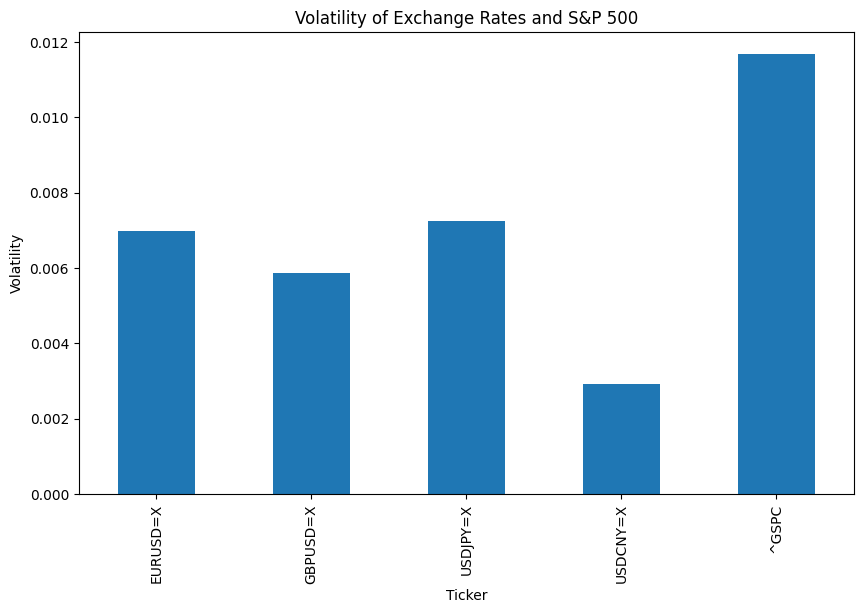

In [31]:
metrics_df["Volatility"].plot(kind='bar', figsize=(10,6))
plt.title('Volatility of Exchange Rates and S&P 500')
plt.xlabel('Ticker')
plt.ylabel('Volatility')
plt.show()

WEEKLY

<Axes: xlabel='Date'>

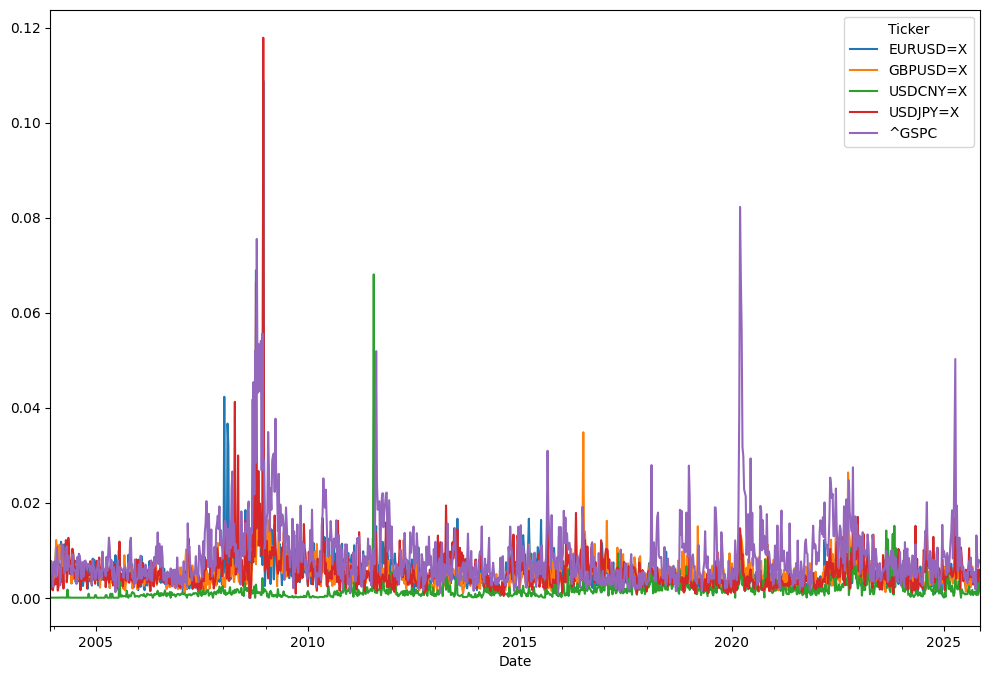

In [32]:
weekly_vol_exchange =data_daily.resample("W").std()

weekly_vol_exchange.plot(figsize=(12,8))

In [33]:
weekly_vol_exchange

Ticker,EURUSD=X,GBPUSD=X,USDCNY=X,USDJPY=X,^GSPC
Date,,,,,
2003-12-07,0.006295,0.005789,0.000006,0.002389,0.005121
2003-12-14,0.003630,0.003641,0.000014,0.006690,0.007722
2003-12-21,0.003561,0.003765,0.000016,0.001799,0.006721
2003-12-28,0.002149,0.003267,0.000007,0.001557,0.002276
2004-01-04,0.002590,0.003153,0.000018,0.003183,0.005940
...,...,...,...,...,...
2025-10-19,0.003059,0.002834,0.003435,0.003522,0.008236
2025-10-26,0.002233,0.000742,0.000621,0.003428,0.006439
2025-11-02,0.002762,0.003116,0.001289,0.005958,0.007917


MONTHLY

C:\Users\miche\AppData\Local\Temp\ipykernel_43196\2838235357.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_vol_exchange =data_daily.resample("M").std()


<Axes: xlabel='Date'>

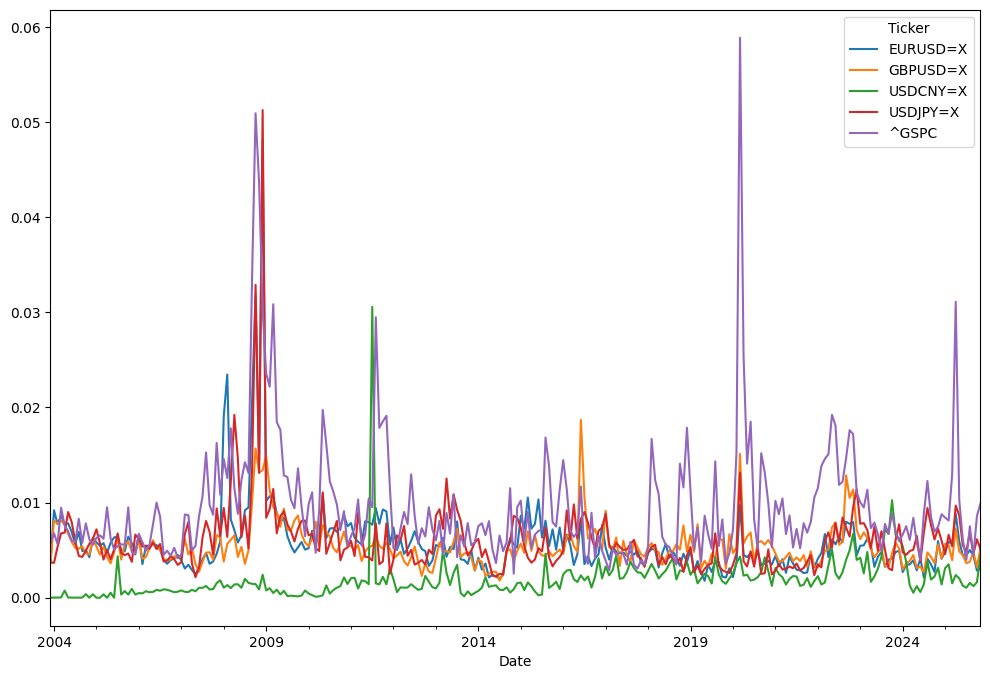

In [34]:
monthly_vol_exchange =data_daily.resample("M").std()
monthly_vol_exchange.plot(figsize=(12,8))

DAILY

In [35]:
tickers_exchange_rates = ["EURUSD=X","GBPUSD=X","USDJPY=X","USDCNY=X", "^GSPC"]

end = dt.datetime.now()
start = end - dt.timedelta(days=365)

data = yf.download(tickers_exchange_rates, start, end, interval = "60m")["Close"].pct_change().dropna()

C:\Users\miche\AppData\Local\Temp\ipykernel_43196\1856706878.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers_exchange_rates, start, end, interval = "60m")["Close"].pct_change().dropna()
[*********************100%***********************]  5 of 5 completed
C:\Users\miche\AppData\Local\Temp\ipykernel_43196\1856706878.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data = yf.download(tickers_exchange_rates, start, end, interval = "60m")["Close"].pct_change().dropna()


<Axes: xlabel='Datetime'>

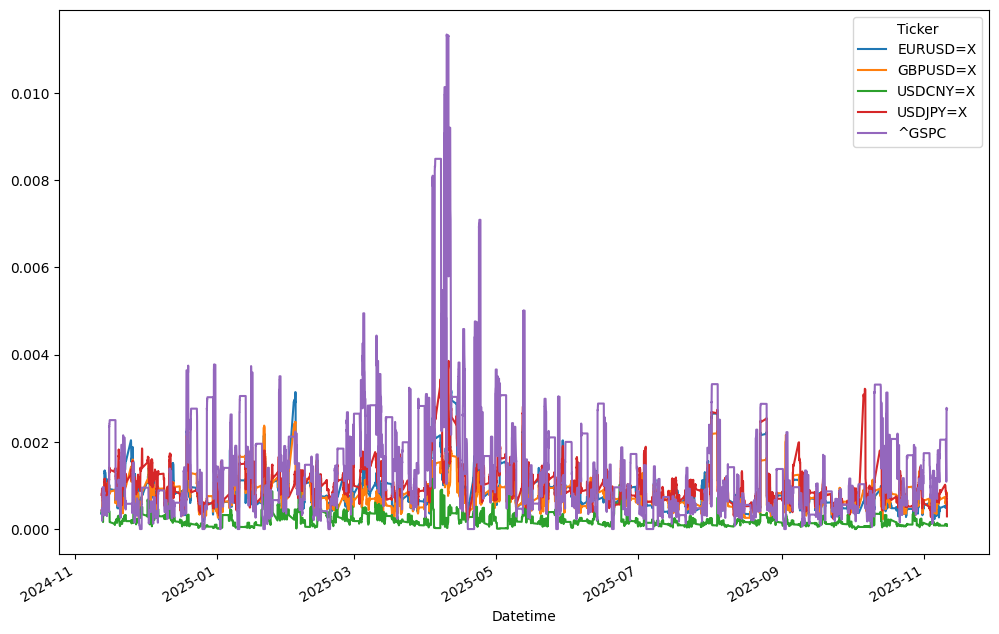

In [36]:
daily_vol_exchange = data.rolling(window=24).std()
daily_vol_exchange.plot(figsize=(12,8))